In [1]:
import torch
from torch import nn
from d2l import torch as d2l

#Bahdanau注意力

#带有注意力机制的解码器基本接口
class AttentionDecoder(d2l.Decoder):
    '''带有注意力机制的解码器基本接口'''
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    def attention_weights(self):
        raise NotImplementedError

In [2]:
#实现带有Bahdanau注意力的循环神经网络解码器
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        #使用加性注意力
        self.attention = d2l.AdditiveAttention(num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    #初始化解码器状态
    def init_state(self, enc_outputs, enc_valid_lens, *args):
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        enc_outputs, hidden_state, enc_valid_lens = state
        X = self.embedding(X).permute(1,0,2)
        outputs, self._attention_weights = [], []
        for x in X:
            #取解码器当前隐藏状态的最上层形状然后增加一个维度，作为query
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            #使用加性注意力计算上下文向量
            context = self.attention(query, enc_outputs, enc_outputs, enc_valid_lens)
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            #计算输出并更新状态
            out, hidden_state = self.rnn(x.permute(1,0,2), hidden_state)
            #将当前输出添加到列表
            outputs.append(out)
            #保存当前步的注意力权重
            self._attention_weights.append(self.attention.attention_weights)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1,0,2), [enc_outputs, hidden_state, enc_valid_lens]

In [3]:
#测试Bahdanau注意力解码器
encoder = d2l.Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
encoder.eval()
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
decoder.eval()
X = torch.zeros((4,7), dtype=torch.long)
state = decoder.init_state(encoder(X), None)
output, state = decoder(X, state)
print(output.shape)
print(len(state))
print(state[0].shape)
print(len(state[1]))
print(state[1][0].shape)

torch.Size([4, 7, 10])
3
torch.Size([4, 7, 16])
2
torch.Size([4, 16])


In [8]:
#粘贴必要函数
def sequence_mask(X, valid_len, value=0):
    '''在序列中屏蔽不相关的项'''
    #获取最大长度（X的第二个维度大小）
    maxlen = X.size(1)
    #构造掩码向量
    mask = torch.arange(
        (maxlen), dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    #替换无效位置的值
    X[~mask] = value
    return X

X = torch.tensor([[1,2,3],
                  [4,5,6]])
print(sequence_mask(X, torch.tensor([1,2])))

class MaskedSoftmaxCEloss(nn.CrossEntropyLoss):
    '''带遮蔽的softmax交叉熵损失函数'''
    def forward(self, pred, label, valid_len):
        #构造权重掩码
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        #修改reduction模式，防止默认损失求平均
        self.reduction = 'none'
        #计算未加权的损失（调用父类的前向传播方法）
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        #加权平均
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    '''训练序列到序列模型'''
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if 'weight' in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCEloss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10,num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)
        for batch in data_iter:
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']]*Y.shape[0],device=device).reshape(-1,1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)
            Y_hat = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch+1, (metric[0]/metric[1],))
    print(f'loss {metric[0]/metric[1]:.3f}, {metric[1]/timer.stop():.3f}'
          f'tokens/sec on {str(device)}')

tensor([[1, 0, 0],
        [4, 5, 0]])


loss 0.021, 12762.888tokens/sec on cuda:0


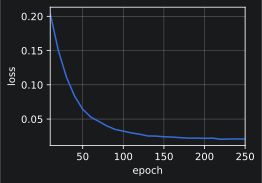

In [9]:
#训练
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 250, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = d2l.Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = d2l.EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [10]:
#将几个英语句子翻译成法语
engs = ['go .','i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est riche ., bleu 0.658
i'm home . => je suis chez moi ., bleu 1.000
